In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from tqdm import tqdm

n = 1
mechanisms = ['MCAR', 'MAR_l', 'MAR_m', 'MAR_h', 'MNAR_l', 'MNAR_m', 'MNAR_h']

mec_labels = {}
for mec in mechanisms:
    if "_" in mec:
        base, sub = mec.split("_")
        mec_label = rf"{base}$_{{{sub.upper()}}}$"
    else:
        mec_label = mec
    mec_labels[mec] = mec_label


mr_values = ["05", "10", "15", "20", "25"]

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
colors = {
    'MCAR':   (0.25, 0.85, 0.35),   # verde vibrante
    'MAR_l':  (1.00, 0.70, 0.30),   # laranja claro
    'MAR_m':  (0.95, 0.50, 0.15),   # laranja médio
    'MAR_h':  (0.80, 0.30, 0.05),   # laranja escuro
    'MNAR_l': (0.45, 0.70, 1.00),   # azul claro
    'MNAR_m': (0.25, 0.50, 0.95),   # azul médio
    'MNAR_h': (0.10, 0.35, 0.85),   # azul escuro
}
EXCLUDED_PATIENTS = ['AJ7TSV9','AS2MVDL']
markers = {'MCAR': 'o', 'MAR_l': 's', 'MAR_m': 'D', 'MAR_h': '^', 'MNAR_l': 'X', 'MNAR_m': 'P', 'MNAR_h': 'H'}

order = ['ATHKM6V', 'AUY8KYW', 'AURCTAK', 'AX6281V', 'AOYM4KG', 'A4G0044', 'A7EM0B6', 'AQC0L71', 'AZIK4ZA', 'AHYIJDV', 'AAXAA7Z', 'A1ZJ41O', 'AFPB8J2', 'ASFODQR', 'A0VFT1N', 'AJWW3IY', 'AV2GF3B', 'AKXN5ZZ', 'A1K5DRI', 'A4E0D03', 'APGIB2T', 'A3OU183', 'AYWIEKR', 'A0NVTRV', 'AIFDJZB', 'A36HR6Y', 'AA2KP1S', 'AJMQUVV', 'AMV7EQF', 'AYEFCWQ']



In [2]:
patients = {}
for metric in ['RHR', 'HROS']:
    patients[metric] = [patient for patient in os.listdir(f"Patients/{metric}")
                        if os.path.isdir(os.path.join(f"Patients/{metric}", patient)) and patient not in EXCLUDED_PATIENTS]

tuples_count = {}
for metric, patient_list in patients.items():
    tuples_count[metric] = {}
    for patient in patient_list:
        try:
            df_full = pd.read_csv(f'Patients/{metric}/{patient}/Anomalies/{patient}_original_anomalies.csv', usecols=[1, 2], header=None)
            tuples_count[metric][patient] = len(df_full)
        except (FileNotFoundError, pd.errors.EmptyDataError):
            print(f"Arquivo completo não encontrado ou vazio para o paciente {patient}. Pulando...")
            tuples_count[metric][patient] = 0
            patients[metric].remove(patient)

            # Concatenate tuples_count into a single DataFrame with a 'metric' column

df_tuples = pd.concat(
    [
        pd.DataFrame({
            'patient': list(p_dict.keys()),
            'tuples_count': list(p_dict.values()),
            'metric': metric
        })
        for metric, p_dict in tuples_count.items()
    ],
    ignore_index=True
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


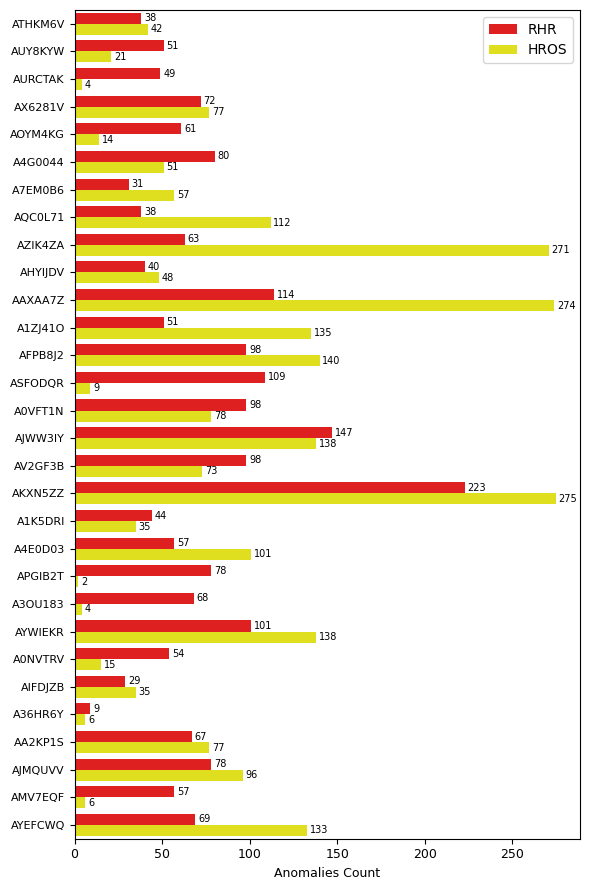

In [29]:
plt.figure(figsize=(6, 9))
palette = {'RHR': 'red', 'HROS': 'yellow'}
ax = sns.barplot(y="patient", x="tuples_count", hue="metric", data=df_tuples, palette=palette, orient="h", order=order)
ax.bar_label(ax.containers[0], fontsize=7, padding=2)
ax.bar_label(ax.containers[1], fontsize=7, padding=2)
plt.ylabel('')
plt.xlabel('Anomalies Count', fontsize=9)
plt.xticks(fontsize=9)
plt.title('')
plt.yticks(fontsize=8)  # Mantém os nomes dos pacientes legíveis
plt.legend(title='')
plt.tight_layout()
plt.savefig('Plots/original_counts.eps', dpi=300)
plt.show()

In [3]:
class ConfusionMatrix:

    metrics_table_mec = {mec: pd.DataFrame(columns=['MR', 'Accuracy', 'Precision', 'Recall', 'F1_Score']) 
            for mec in mechanisms}

    def __init__(self, metric):
        self.metric = metric
        self.patients = [patient for patient in os.listdir(f"Patients/{self.metric}") 
                         if os.path.isdir(os.path.join(f"Patients/{self.metric}", patient)) and patient not in EXCLUDED_PATIENTS]
        self._plot_og_anomalies()
        self._metrics_df()

    def _intervals_overlap(self, a, b):
        """Verifica se os intervalos a e b se sobrepõem"""
        return max(a[0], b[0]) <= min(a[1], b[1])

    def _match_event_intervals(self, y_true, y_pred):
        """
        Compara listas de intervalos (eventos reais e previstos).
        Cada intervalo é uma tupla: (inicio, fim)

        Retorna TP, FP, FN
        """
        matched = set()

        for i, pred in enumerate(y_pred):
            for j, true in enumerate(y_true):
                if self._intervals_overlap(pred, true):
                    matched.add(j)
                    break  # conta só uma correspondência

        TP = len(matched)
        FP = len(y_pred) - TP
        FN = len(y_true) - TP

        return TP, FP, FN 
    
    # Iterar sobre os pacientes e contar as tuplas no dataset completo (df_full)
    def _plot_og_anomalies(self):
        tuples_count = {}
        for patient in self.patients:
            if patient in EXCLUDED_PATIENTS:
                continue
            try:
                df_full = pd.read_csv(f'Patients/{self.metric}/{patient}/Anomalies/{patient}_original_anomalies.csv', usecols=[1, 2], header=None)
                tuples_count[patient] = len(df_full)
            except (FileNotFoundError, pd.errors.EmptyDataError):
                print(f"Arquivo completo não encontrado ou vazio para o paciente {patient}. Pulando...")
                tuples_count[patient] = 0
                self.patients.remove(patient)

        # Plotar os resultados
        plt.figure(figsize=(15, 6))
        plt.bar(tuples_count.keys(), tuples_count.values(), color='skyblue')
        plt.xlabel('Pacientes')
        plt.ylabel('Quantidade de Tuplas')
        plt.title('Quantidade de Tuplas nos Datasets de Todos os Pacientes')
        plt.xticks(rotation=45)
        # Adicionar os valores absolutos acima de cada barra
        for i, (patient, count) in enumerate(tuples_count.items()):
            plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=8)
        plt.show()

    def _metrics_df(self):

        print(f"Calculando métricas para {self.metric}...")

        for mec in mechanisms:

            results = {}
            absolute = {}

            # Adicionar barra de progresso
            for patient in tqdm(self.patients, desc=f"Processando pacientes para {mec}"):
                
                # Carregar df_full
                try:
                    df_full = pd.read_csv(f'Patients/{self.metric}/{patient}/Anomalies/{patient}_original_anomalies.csv', header=None)
                except (FileNotFoundError, pd.errors.EmptyDataError):
                    print(f"Arquivo completo não encontrado ou vazio para o paciente {patient}. Pulando...")
                    continue
                
                # Inicializar dfs_miss
                dfs_miss = {}
                for mr_value in mr_values:
                    dfs_miss[mr_value] = {}
                    for i in range(1, n + 1):
                        file_path = f'Patients/{self.metric}/{patient}/Anomalies/{mec}/{i}/{patient}_anomalies_{mec}_{i}_{mr_value}.csv'
                        if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
                            dfs_miss[mr_value][i] = pd.read_csv(file_path, usecols=[1, 2], header=None)
                        else:
                            if not os.path.exists(file_path):
                                continue
                            elif os.path.getsize(file_path) == 0:
                                dfs_miss[mr_value][i] = pd.DataFrame(columns=[1, 2])  

                precision_list = {mr: [] for mr in mr_values}
                recall_list = {mr: [] for mr in mr_values}

                for mr, dfs in dfs_miss.items():
                    for key, df_miss in dfs.items():
                        y_true_intervals = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in zip(df_full[1], df_full[1])]
                        y_pred_intervals = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in zip(df_miss[1], df_miss[1])]

                        TP, FP, FN = self._match_event_intervals(y_true_intervals, y_pred_intervals)

                        if mr not in absolute:
                            absolute[mr] = {'TP': [], 'FP': [], 'FN': []}
                        absolute[mr]['TP'].append(TP)
                        absolute[mr]['FP'].append(FP)
                        absolute[mr]['FN'].append(FN)

                        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
                        recall = TP / (TP + FN) if (TP + FN) > 0 else 0

                        precision_list[mr].append(precision)
                        recall_list[mr].append(recall)

                mean_precision_by_mr = {mr: [] for mr in mr_values}
                mean_recall_by_mr = {mr: [] for mr in mr_values}

                for mr in mr_values:
                    precision_sum = sum(precision_list[mr])
                    recall_sum = sum(recall_list[mr])
                    count = len(precision_list[mr])

                    mean_precision_by_mr[mr] = precision_sum / count if count > 0 else 0
                    mean_recall_by_mr[mr] = recall_sum / count if count > 0 else 0

                for mr in mr_values:
                    if mr not in results:
                        results[mr] = {'precision': [], 'recall': []}
                    results[mr]['precision'].append(mean_precision_by_mr[mr])
                    results[mr]['recall'].append(mean_recall_by_mr[mr])

            # Inicializar os valores totais de TP, FP, FN
            # Inicializar os valores totais de TP, FP, FN por MR
            total_tp_by_mr = {mr: sum(values['TP']) for mr, values in absolute.items()}
            total_fp_by_mr = {mr: sum(values['FP']) for mr, values in absolute.items()}
            total_fn_by_mr = {mr: sum(values['FN']) for mr, values in absolute.items()}

            # Inicializar listas para armazenar as métricas
            accuracy_list = []
            precision_list = []
            f1_list = []
            recall_list = []

            # Calcular métricas para cada MR
            for mr in mr_values:
                tp = total_tp_by_mr[mr]
                fp = total_fp_by_mr[mr]
                fn = total_fn_by_mr[mr]
                total_instances = tp + fp + fn

                # Calcular acurácia, precisão, revocação e F1
                accuracy = tp / total_instances if total_instances > 0 else 0
                precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

                # Adicionar métricas às listas
                accuracy_list.append(accuracy * 100)
                precision_list.append(precision * 100)
                recall_list.append(recall * 100)
                f1_list.append(f1 * 100)

            # Criar um DataFrame com as métricas
            metrics_table = pd.DataFrame({
                'MR': mr_values,
                'Accuracy': accuracy_list,
                'Precision': precision_list,
                'Recall': recall_list,
                'F1_Score': f1_list
            })

            # Adicionar a tabela de métricas ao DataFrame geral
            self.metrics_table_mec[mec] = metrics_table

            # Exibir a tabela
            print(metrics_table)



In [16]:
def metric_lineplot(matrix):
    fig, axs = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

    for idx, metric in enumerate(metric_names):
        for mec_name, table in matrix.metrics_table_mec.items():
            axs[idx].plot(table['MR'], table[metric], marker=markers.get(mec_name, 'o'), label=mec_labels.get(mec_name, mec_name), color=colors.get(mec_name, 'black'))
            axs[idx].set_title(metric, fontsize=9)
            axs[idx].set_ylim(0, 100)
            axs[idx].set_xticks(mr_values)
            axs[idx].set_xticklabels(mr_values, fontsize=9)
            #axs[idx].set_xlabel('Missing Rate (%)')
            axs[idx].set_ylabel('Value (%)' if idx == 0 else "", fontsize=9)
            axs[idx].set_xticklabels(mr_values, fontsize=9)
            axs[idx].grid(True)

    fig.supxlabel('Missing Rate (%)', fontsize=9, y=0.05)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(mechanisms), fontsize=9)
    for ax in axs:
        ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(f'Plots/Lineplots/metrics_{matrix.metric}.eps', dpi=300, bbox_inches='tight')
    plt.show()


def pr_lineplot(matrix):
    plt.figure(figsize=(8, 6))

    # Add text annotations for first and last points of MNAR_l
    mnar_l_table = matrix.metrics_table_mec['MNAR_h']
    
    
    plt.text(mnar_l_table['Recall'].iloc[0] - 2.8, mnar_l_table['Precision'].iloc[0] + 1.8,
             f"MR: {mnar_l_table['MR'].iloc[0]}%", fontsize=7, va='center', color=colors.get('MNAR_c', 'black'))
    plt.text(mnar_l_table['Recall'].iloc[-1] - 4, mnar_l_table['Precision'].iloc[-1] + 1.8, 
             f"MR: {mnar_l_table['MR'].iloc[-1]}%", fontsize=7, va='center', color=colors.get('MNAR_c', 'black'))

    for mec_name, table in matrix.metrics_table_mec.items():
        plt.plot(table['Recall'], table['Precision'], marker=markers.get(mec_name, 'o'), 
                    label=mec_labels.get(mec_name, mec_name), color=colors.get(mec_name, 'black'))


    plt.xlabel('Recall (%)', fontsize=8)
    plt.xticks(fontsize=8)
    plt.ylabel('Precision (%)', fontsize=8)
    plt.yticks(fontsize=8)
    plt.xlim(20, 100)
    plt.ylim(40, 100)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='', loc='upper left', fontsize=9)
    plt.savefig(f'Plots/Lineplots/pr_plot_{matrix.metric}.eps', dpi=300, bbox_inches='tight')
    plt.show()

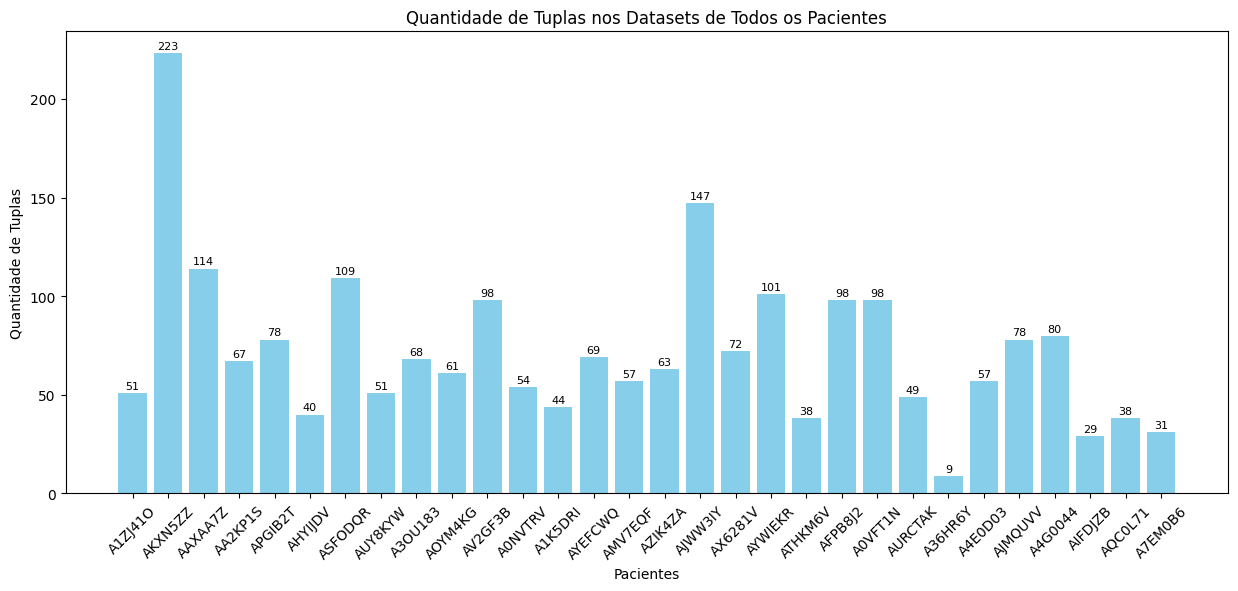

Calculando métricas para RHR...


Processando pacientes para MCAR: 100%|██████████| 30/30 [02:19<00:00,  4.67s/it]


   MR   Accuracy  Precision     Recall   F1_Score
0  05  79.290532  89.232499  87.679558  88.449213
1  10  68.333597  82.926829  79.521179  81.188305
2  15  60.317218  77.823691  72.836096  75.247336
3  20  53.746408  72.891687  67.173112  69.915660
4  25  48.020517  69.031052  61.206262  64.883596


Processando pacientes para MAR_l:  17%|█▋        | 5/30 [00:34<02:52,  6.90s/it]


CPU times: user 2min 54s, sys: 64.7 ms, total: 2min 54s
Wall time: 2min 55s


KeyboardInterrupt: 

In [5]:
%%time
results_rhr = ConfusionMatrix("RHR")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


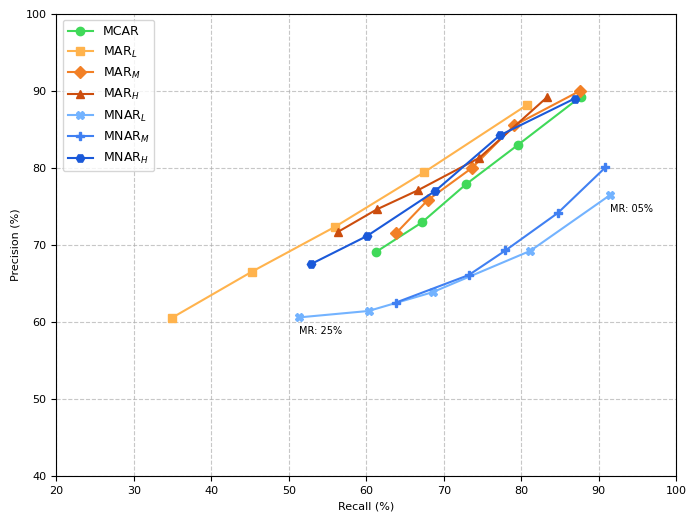

In [27]:
pr_lineplot(results_rhr)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


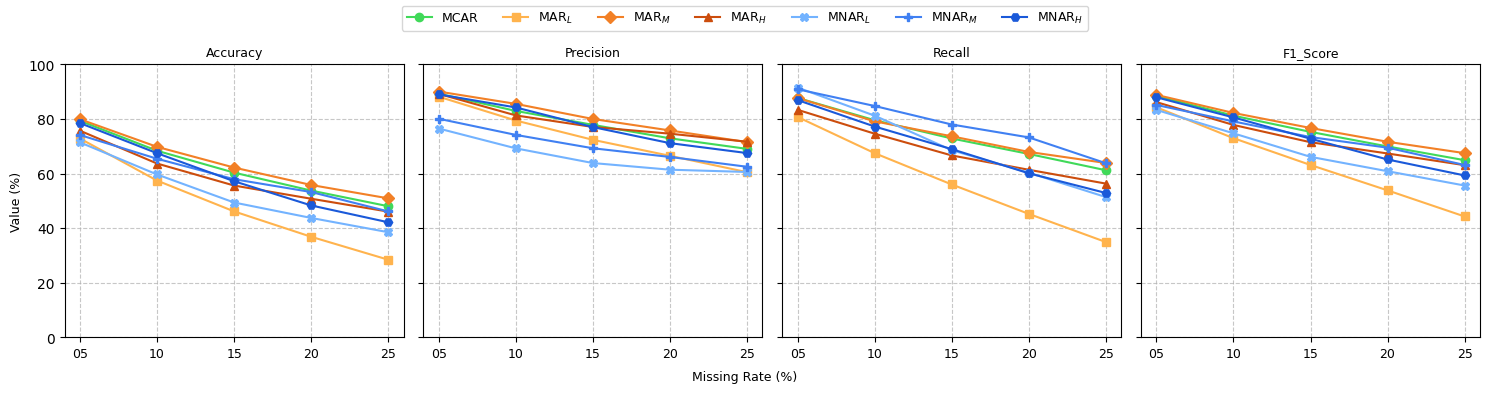

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


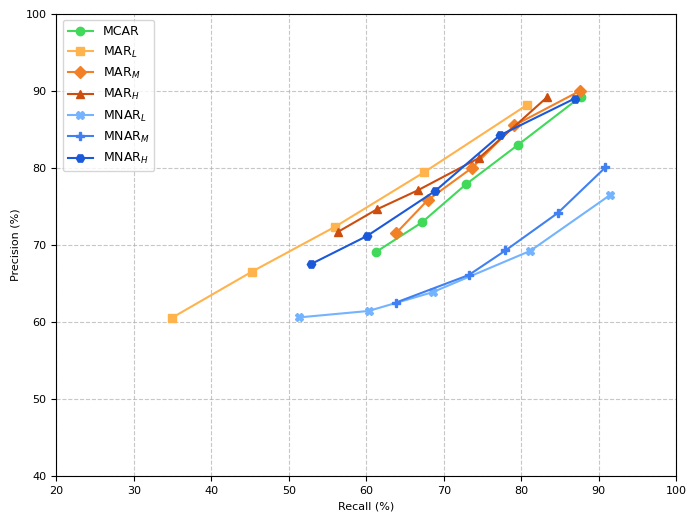

In [ ]:
metric_lineplot(results_rhr)


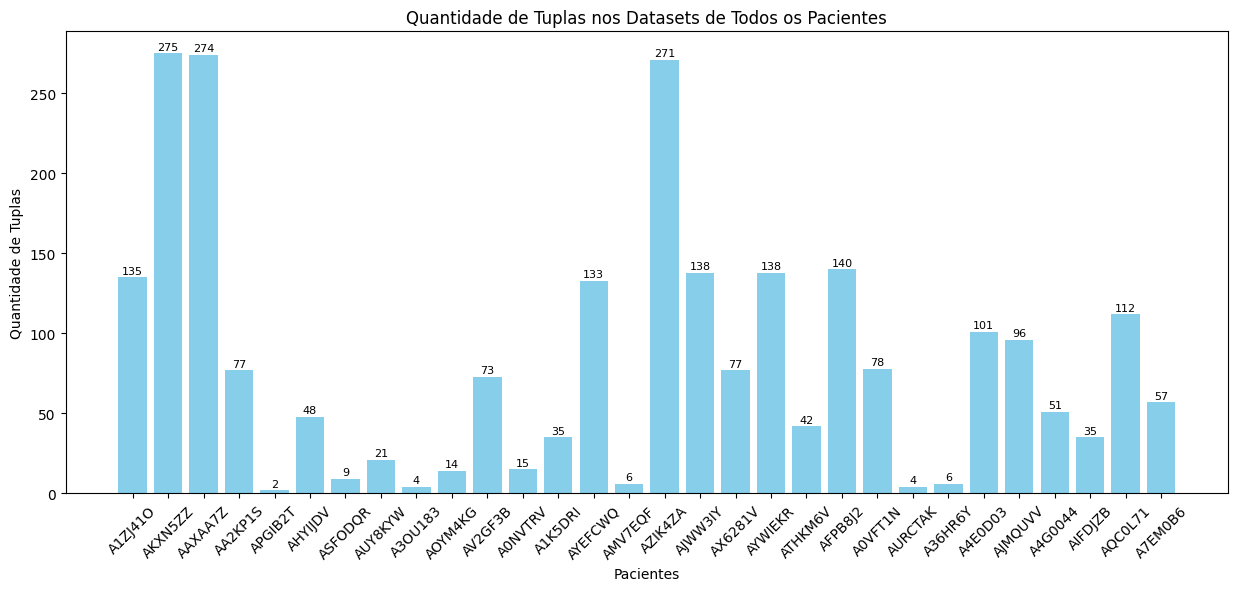

Calculando métricas para HROS...


Processando pacientes para MCAR: 100%|██████████| 30/30 [02:52<00:00,  5.73s/it]


   MR   Accuracy  Precision     Recall   F1_Score
0  05  80.778876  89.954825  88.788002  89.367605
1  10  70.321995  83.551867  81.621403  82.575354
2  15  62.459764  78.328147  75.508715  76.892595
3  20  57.234307  74.659168  71.033644  72.801296
4  25  53.091415  70.684286  68.082692  69.359101


Processando pacientes para MAR_l: 100%|██████████| 30/30 [02:37<00:00,  5.26s/it]


   MR   Accuracy  Precision     Recall   F1_Score
0  05  76.561922  89.692508  83.948115  86.725293
1  10  64.757865  83.500456  74.260235  78.609740
2  15  56.000000  79.781962  65.261451  71.794872
3  20  48.784663  75.838212  57.762465  65.577543
4  25  43.145840  71.845205  51.925415  60.282353


...

   MR   Accuracy  Precision     Recall   F1_Score
0  05  82.897294  91.403610  89.906769  90.649011
1  10  74.701181  88.667421  82.586137  85.518805
2  15  67.343134  85.364967  76.132955  80.485087
3  20  60.184266  82.711600  68.844751  75.143793
4  25  52.967471  77.735164  62.440211  69.253248


Processando pacientes para MNAR_m: 100%|██████████| 30/30 [02:41<00:00,  5.38s/it]


   MR   Accuracy  Precision     Recall   F1_Score
0  05  58.128914  74.855079  72.233482  73.520918
1  10  46.907825  66.781701  61.183624  63.860213
2  15  40.813946  62.696841  53.903527  57.968614
3  20  35.079552  56.224027  48.261046  51.939100
4  25  30.567041  52.968270  41.953790  46.821986


Processando pacientes para MNAR_h: 100%|██████████| 30/30 [02:29<00:00,  4.98s/it]

   MR   Accuracy  Precision     Recall   F1_Score
0  05  47.570773  69.019426  60.486421  64.471808
1  10  34.984084  58.820502  46.331577  51.834384
2  15  27.793765  51.620087  37.584110  43.497842
3  20  23.509289  46.316523  32.314552  38.068860
4  25  21.012433  43.793189  28.771788  34.727726
CPU times: user 18min 13s, sys: 618 ms, total: 18min 14s
Wall time: 18min 48s


In [6]:
%%time
results_hros = ConfusionMatrix("HROS")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


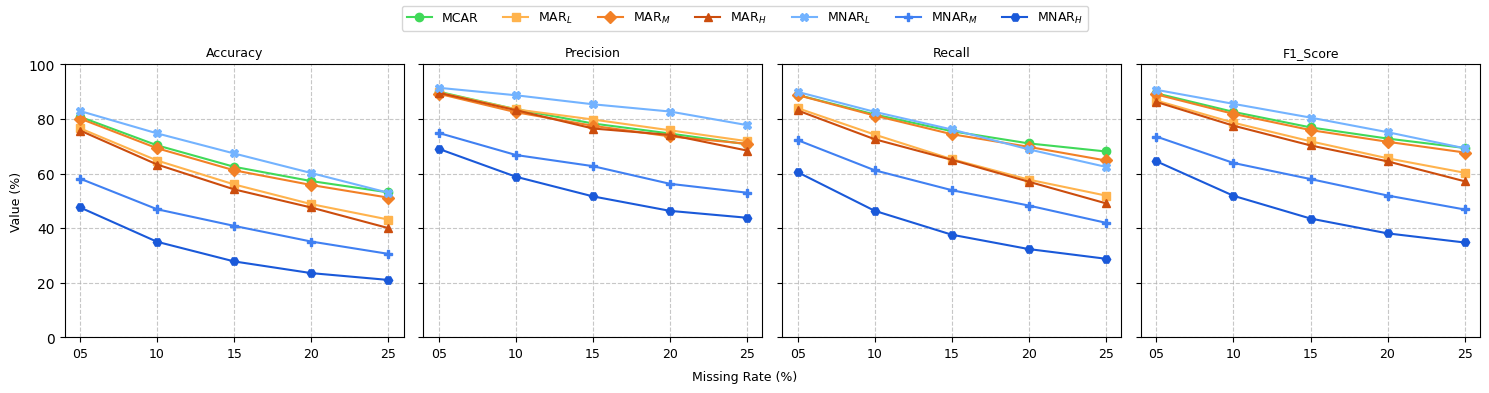

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


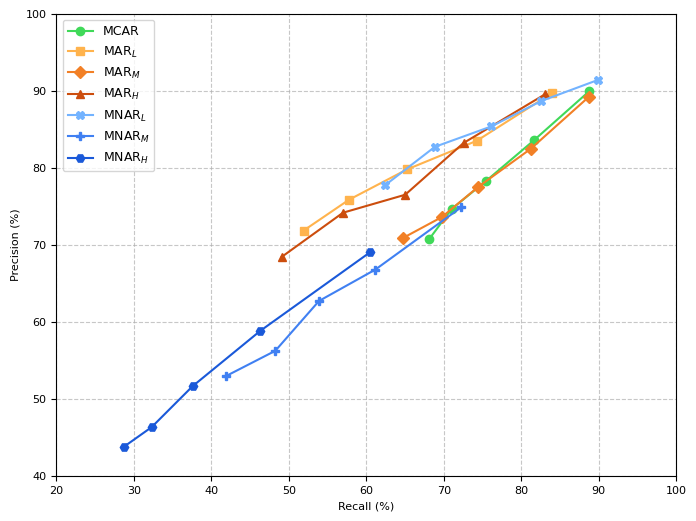

In [ ]:
metric_lineplot(results_hros)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


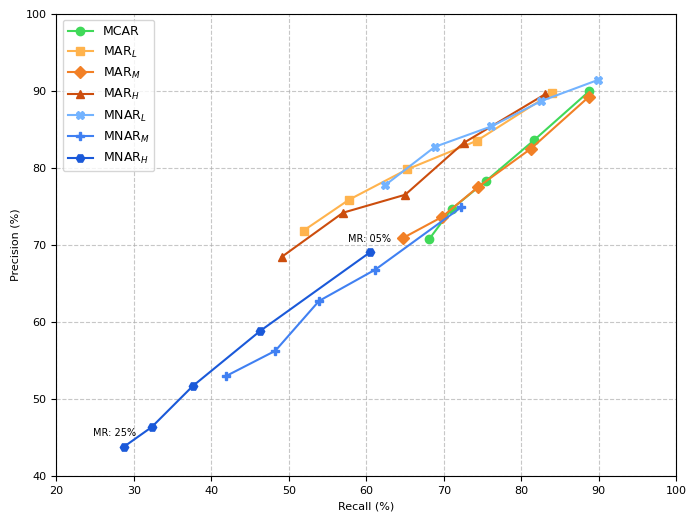

In [17]:
pr_lineplot(results_hros)